# DISORT + Monte Carlo two-level iteration (radex-style optics)

This notebook is copied from example_disort.ipynb, but binds the DISORT solver to NonLTE_optics_redex.py so the optical-depth calculation uses the pythonradex-style line-profile convention. The original example_disort.ipynb is unchanged.


In [1]:
import sys
sys.path.append('../')  # Adjust the path

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import Constants as constants
from ComaGrid import ComaGrid
from Einstein_coeff import einstein_coeffs_B
from Electron_collision import electron_collision_rate
from Molecular_collision import detailed_balance_excitation_rate, molecular_collision_rate, ww_sigma_ul_m2
from profiles import calc_density, velocity_tanh, temperature_inverse_distance, electron_biver_1997
from Solar_pumping import scale_g_factors_from_1au
from Statistical_equilibrium import monte_carlo_two_level_populations
import disort_solver as disort_solver_radex
from NonLTE_optics_redex import (
    nonlte_excitation_temperature as redex_nonlte_excitation_temperature,
    nonlte_tau as redex_nonlte_tau,
    thermal_fwhm_velocity,
)

disort_solver_radex.nonlte_tau = redex_nonlte_tau
disort_solver_radex.nonlte_excitation_temperature = redex_nonlte_excitation_temperature
solve_disort_layers = disort_solver_radex.solve_disort_layers




In [3]:
data_path =  "../data/r_lev0_2.5au.csv"

profile = np.loadtxt(data_path, delimiter=",")
radius_km = profile[::-1, 0]
level0_ratio = profile[::-1, 1] + 0.4 * (1 - profile[::-1, 1])
level0_ratio= np.ones_like(level0_ratio)
level1_ratio=1-level0_ratio


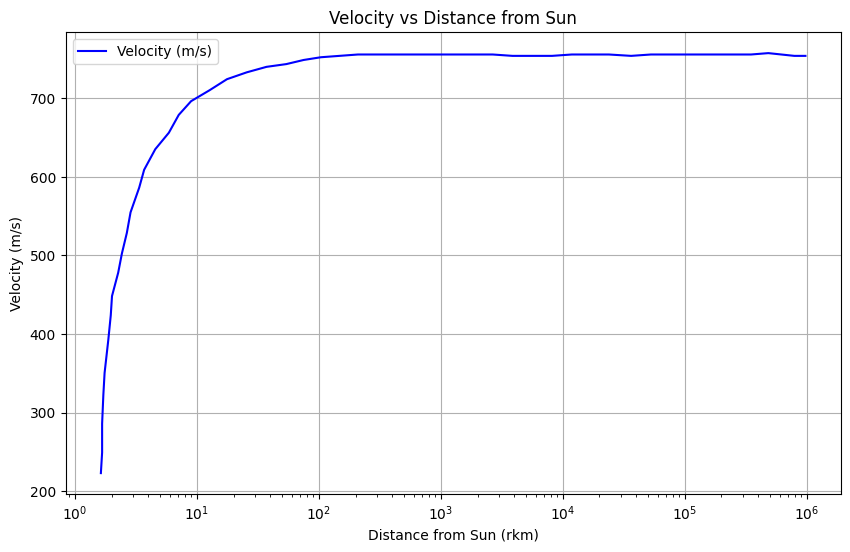

In [4]:
# read the csv file 'vel25au.csv', 1st column is rkm, 2nd column is velocity
import csv
import numpy as np
import matplotlib.pyplot as plt
rkm = []
velocity = []
with open('../vel25au.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        rkm.append(float(row[0]))
        velocity.append(float(row[1]))
rkm = np.array(rkm)
velocity = np.array(velocity)

# plot velocity vs rkm
plt.figure(figsize=(10, 6))
plt.semilogx(rkm, velocity, label='Velocity (m/s)', color='blue')
plt.xlabel('Distance from Sun (rkm)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Distance from Sun')
plt.grid()
plt.legend()
plt.show()


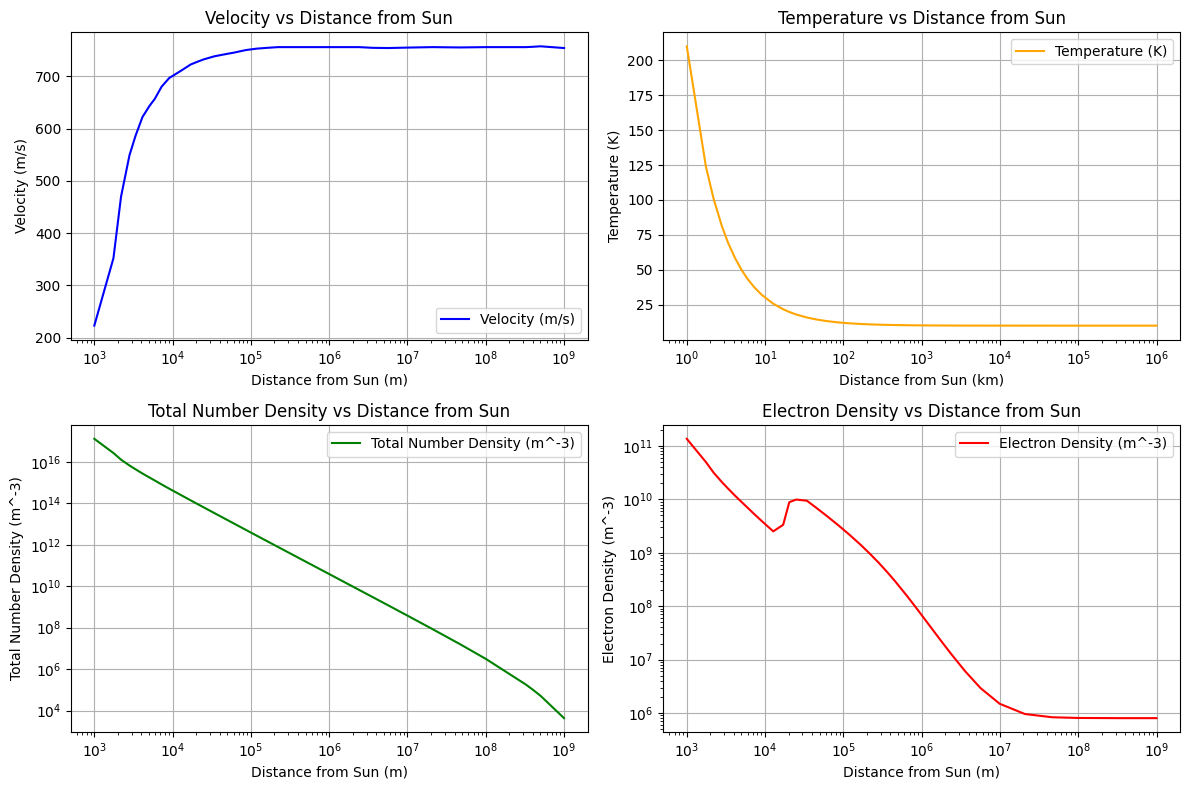

In [5]:
# Transition parameters
nu_Hz = 556.936e9
A_ul_s_1 = 3.456e-3
g_u = 9.0
g_l = 9.0
absorber_mass_kg = 18.01528 * constants.ATOMIC_MASS_UNIT

# Coma setup matching examples/coma.ipynb
heliocentric_distance_AU = 2.5
xc = radius_km * 1.0e3
xf = np.empty(xc.size + 1, dtype=np.float64)
xf[1:-1] = np.sqrt(xc[:-1] * xc[1:])
xf[0] = xc[0] ** 2 / xf[1]
xf[-1] = xc[-1] ** 2 / xf[-2]
nlayer = xc.size

v0 = 720.0
c_scale = 3.5e3
# velocity = velocity_tanh(xc, v0=v0, c=c_scale)
velocity = np.interp(xc, rkm*1e3, velocity)

T0 = 10.0
temperature = temperature_inverse_distance(xc, a=10, b=1, t0=T0, r0=2000)

Q = 3.7e26
total_number_density = calc_density(
    Q,
    xc,
    velocity,
    r_h=heliocentric_distance_AU,
    model_type='isotropic',
    photo_dissociation=True,
)
nelec, telec = electron_biver_1997(
    Q,
    r_h=heliocentric_distance_AU,
    r=xc,
    v=velocity,
    t_kin=temperature,
    t_emax=10000,
)

# Initial level ratios: rL0 = 0.5, rL1 = 0.5
fractions = np.zeros((nlayer, 1), dtype=np.float64)
fractions[:, 0] = level1_ratio
coma = ComaGrid(
    temperature=temperature,
    total_number_density=total_number_density,
    velocity=velocity,
    nelec=nelec,
    telec=telec,
    fractions=fractions,
)

coma.xf = xf
coma.xc = xc


# plot the profiles
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.semilogx(xc, velocity, label='Velocity (m/s)', color='blue')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Distance from Sun')
plt.grid()
plt.legend()    
plt.subplot(2, 2, 2)
plt.semilogx(xc/1000, temperature, label='Temperature (K)', color='orange')
plt.xlabel('Distance from Sun (km)')
plt.ylabel('Temperature (K)')
plt.title('Temperature vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 3)
plt.loglog(xc, total_number_density, label='Total Number Density (m^-3)', color='green')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Total Number Density (m^-3)')
plt.title('Total Number Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.subplot(2, 2, 4)
plt.loglog(xc, nelec, label='Electron Density (m^-3)', color='red')
plt.xlabel('Distance from Sun (m)')
plt.ylabel('Electron Density (m^-3)')
plt.title('Electron Density vs Distance from Sun')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()






Fitted sigma_0: 2.89e-18 m^2, beta: -1.00


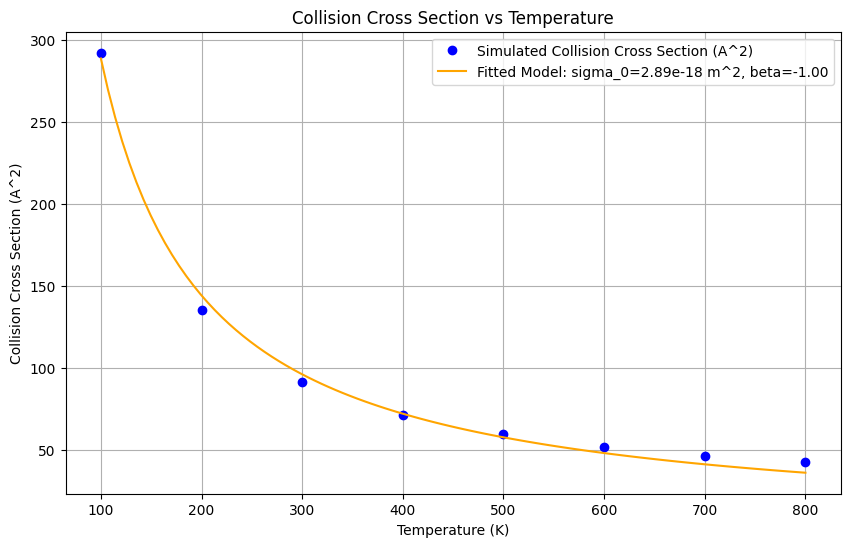

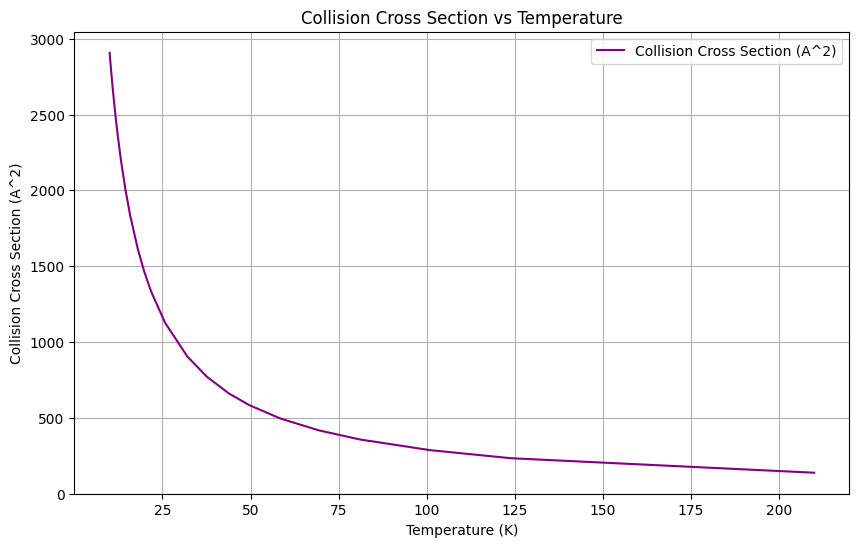

In [6]:
Ts= [100, 200, 300, 400, 500, 600, 700, 800]
simhs = np.array([292.4, 135.2, 91.6, 71.3, 59.5, 51.8, 46.4, 42.3]) * 1e-20

# use ww_sigma_ul_m2 to fit the data, to get alphe and beta
from scipy.optimize import curve_fit
def sigma_model(T, sigma_0, beta):
    return sigma_0 * (T / 100.) ** beta
popt, pcov = curve_fit(sigma_model, Ts, simhs)
sigma_0_fit, beta_fit = popt
print(f"Fitted sigma_0: {sigma_0_fit:.2e} m^2, beta: {beta_fit:.2f}")

# plot the data and the fit
plt.figure(figsize=(10, 6))
plt.plot(Ts, simhs*1e20, 'o', label='Simulated Collision Cross Section (A^2)', color='blue')
T_fit = np.linspace(min(Ts), max(Ts), 100)
sigma_fit = sigma_model(T_fit, *popt)
plt.plot(T_fit, sigma_fit*1e20, label=f'Fitted Model: sigma_0={sigma_0_fit:.2e} m^2, beta={beta_fit:.2f}', color='orange')
plt.xlabel('Temperature (K)')
plt.ylabel('Collision Cross Section (A^2)')
plt.title('Collision Cross Section vs Temperature')
plt.grid()
plt.legend()
plt.show()


simgas= sigma_model(temperature, *popt)
# to A2: 1e20
simgas_A2 = simgas * 1e20

# plot sigma vs temperature
plt.figure(figsize=(10, 6))
plt.plot(temperature, simgas_A2, label='Collision Cross Section (A^2)', color='purple')
plt.xlabel('Temperature (K)')
plt.ylabel('Collision Cross Section (A^2)')
plt.title('Collision Cross Section vs Temperature')
plt.grid()
plt.legend()
plt.show()

In [7]:


B_ul_SI, B_lu_SI = einstein_coeffs_B(
    nu_Hz=nu_Hz,
    A_ul_s_1=A_ul_s_1,
    g_u=g_u,
    g_l=g_l,
)
Cm_ul_s_1 = np.asarray(
    molecular_collision_rate(coma.total_number_density, coma.temperature, sigma_ul_m2=simgas),
    dtype=np.float64,
)
Cm_lu_s_1 = np.asarray(
    detailed_balance_excitation_rate(
        Cm_ul_s_1,
        coma.temperature,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
    ),
    dtype=np.float64,
)
electron_rates = np.array(
    [
        electron_collision_rate(
            n_e=float(n_e),
            t_e=float(t_e),
            nu_Hz=nu_Hz,
            A_ul_s_1=A_ul_s_1,
            g_u=g_u,
            g_l=g_l,
        )
        for n_e, t_e in zip(coma.nelec, coma.telec)
    ],
    dtype=np.float64,
)
Ce_ul_s_1 = electron_rates[:, 0]
Ce_lu_s_1 = electron_rates[:, 1]
G_ul_s_1, G_lu_s_1 = scale_g_factors_from_1au(heliocentric_distance_AU)
G_ul_s_1 = np.full(nlayer, G_ul_s_1, dtype=np.float64)
G_lu_s_1 = np.full(nlayer, G_lu_s_1, dtype=np.float64)

print('Heliocentric distance (AU):', heliocentric_distance_AU)
print('Production rate Q (s^-1):', Q)
print('Initial lower-level density:', coma.density[:, 0])
print('Initial upper-level density:', coma.density[:, 1])


Heliocentric distance (AU): 2.5
Production rate Q (s^-1): 3.7e+26
Initial lower-level density: [4.27799620e+03 5.17281010e+04 1.00747504e+05 1.80638634e+05
 3.07350311e+06 1.59983499e+07 8.55603754e+07 3.87447610e+08
 1.20609238e+09 2.97857793e+09 6.70153201e+09 1.15145534e+10
 1.97783958e+10 3.39653838e+10 5.32945532e+10 9.14964440e+10
 1.88060127e+11 2.95001556e+11 4.84043452e+11 7.94195927e+11
 1.42813379e+12 2.81155029e+12 5.29860794e+12 1.04736075e+13
 1.97661503e+13 3.40760750e+13 6.44990803e+13 9.73712445e+13
 1.40483937e+14 2.56535328e+14 5.13645734e+14 8.25131908e+14
 1.28157837e+15 1.79328726e+15 2.77884079e+15 4.41818125e+15
 6.76634800e+15 1.29595465e+16 2.71524291e+16 1.31919791e+17]
Initial upper-level density: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


LVG effective path / shell thickness: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
....temf... tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
       dtype=torch.float64)
....temf... tensor([[  3.7869,   3.7870,   3.7870,   3.7870,   3.7873,   3.7889,   3.7966,
           3.8296,   3.9198,   4.0956,   4.3822,   4.7238,   5.1063,   5.5941,
           6.1425,   6.8148,   7.8454,   8.9230,   9.8657,  10.8406,  11.8015,
          12.7259,  13.5070,  14.2469,  15.1476,  16.2557,  17.8327,  19.6298,
          21.1986,  23.7781,  28.7796,  34.7306,  40.6176,  46.6042,  53.9321,
          63.8157,  75.1093,  90.9415, 112.4085, 166.9257, 209.9553]],
       dtype=torch.float64)
....temf... tensor([[  5.6411,   5.6412,   5.6415,   5.6419,   5.6447,   5.6538,   5.6752,
           5.7236,


 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good accuracy

 ******* WARNING >>>>>>  check_inputs--vertical temperature step may be too large for good

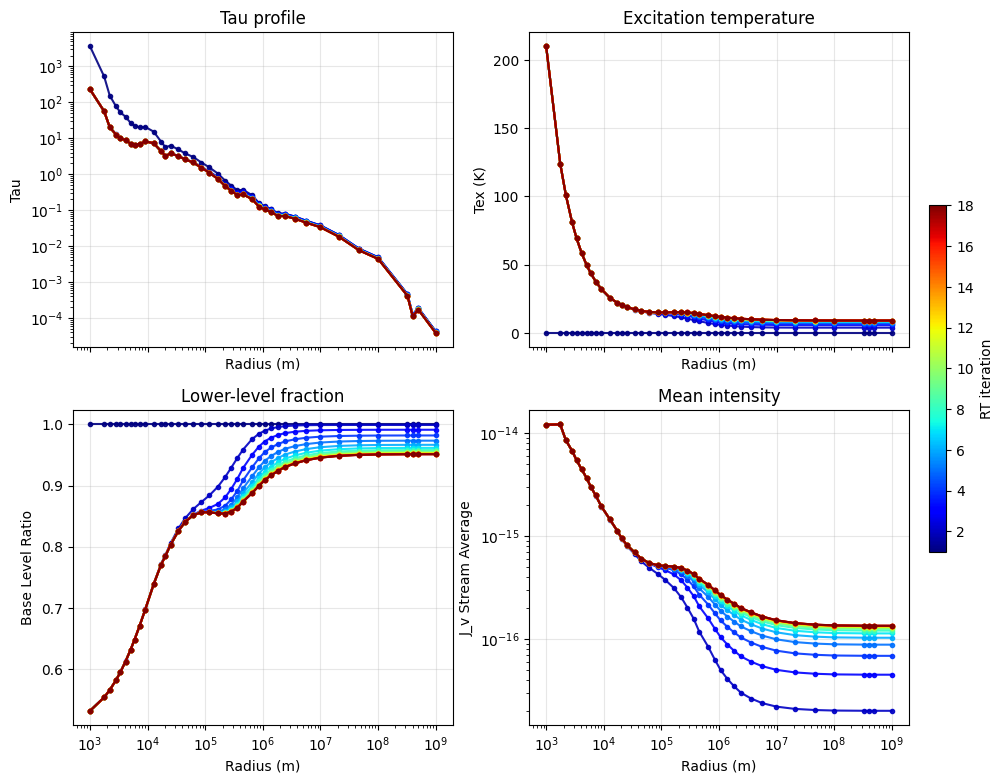

Final J_v_stream_average: [1.35345747e-16 1.35387315e-16 1.35443304e-16 1.35547228e-16
 1.36492397e-16 1.38831112e-16 1.43729187e-16 1.53082681e-16
 1.66368444e-16 1.82576864e-16 2.01408712e-16 2.21005261e-16
 2.42650338e-16 2.68541952e-16 2.98292373e-16 3.37126873e-16
 3.85624018e-16 4.29678530e-16 4.64167905e-16 4.90959744e-16
 5.06655752e-16 5.13225720e-16 5.21888741e-16 5.49134711e-16
 6.04712196e-16 6.96656666e-16 8.23640469e-16 9.58692407e-16
 1.13200097e-15 1.45777948e-15 1.94258544e-15 2.47803238e-15
 3.02323780e-15 3.64074753e-15 4.44327850e-15 5.43794259e-15
 6.71443508e-15 8.47629734e-15 1.20743284e-14 1.20164658e-14]
Final relative change: [7.57955419e-04 7.57974782e-04 7.58000811e-04 7.58048824e-04
 7.58464970e-04 7.59393651e-04 7.60776720e-04 7.61503112e-04
 7.58644637e-04 7.48965424e-04 7.30155633e-04 7.03658001e-04
 6.66893821e-04 6.17033533e-04 5.54900333e-04 4.69843860e-04
 3.65621604e-04 2.72271057e-04 1.93628556e-04 1.23406579e-04
 6.58917642e-05 2.64892772e-05 7.36

In [8]:
max_rt_iterations = 2000
jv_rtol = 1.0e-3
jv_floor = 1.0e-30
population_tolerance = 1.0e-10
packet_fraction_range = (0.05, 0.35)
random_seed = 7

history = []
previous_jv = None
converged = False

radial_shell_thickness_m = np.abs(np.diff(coma.xf))
dv_dr_s_1 = np.gradient(
    np.asarray(coma.velocity, dtype=np.float64),
    np.asarray(coma.xc, dtype=np.float64),
)
sobolev_width_m_s = thermal_fwhm_velocity(
    np.asarray(coma.temperature, dtype=np.float64),
    absorber_mass_kg=absorber_mass_kg,
)
sobolev_length_m = sobolev_width_m_s / np.maximum(np.abs(dv_dr_s_1), 1.0e-300)
lvg_path_length_m = np.minimum(radial_shell_thickness_m, sobolev_length_m)
lvg_width_m_s = 2.0 * np.asarray(coma.velocity, dtype=np.float64)

print('LVG effective path / shell thickness:', lvg_path_length_m / radial_shell_thickness_m)

for iteration in range(1, max_rt_iterations + 1):
    disort_result = solve_disort_layers(
        coma,
        lower_level=0,
        upper_level=1,
        nu_Hz=nu_Hz,
        A_ul_s_1=A_ul_s_1,
        g_u=g_u,
        g_l=g_l,
        absorber_mass_kg=absorber_mass_kg,
        line_profile_type='rectangular',
        width_v_fwhm_m_s=lvg_width_m_s,
        path_length_m=lvg_path_length_m,
        nstreams=16,
    )
    jv_average_stream = np.asarray(disort_result['J_v_stream_average'], dtype=np.float64)

    tau_profile = np.asarray(disort_result['tau_profile'], dtype=np.float64)
    excitation_temperature = np.asarray(disort_result['excitation_temperature_K'], dtype=np.float64)
    base_level_ratio = coma.density[:, 0] / np.maximum(coma.density[:, 0] + coma.density[:, 1], 1.0e-300)

    if previous_jv is None:
        relative_change = np.full_like(jv_average_stream, np.inf)
    else:
        scale = np.maximum(np.abs(previous_jv), jv_floor)
        relative_change = np.abs(jv_average_stream - previous_jv) / scale
        if np.all(relative_change <= jv_rtol):
            history.append({
                'iteration': iteration,
                'J_v_stream_average': jv_average_stream.copy(),
                # 'J_v_quadrature': np.asarray(disort_result['J_v'], dtype=np.float64).copy(),
                'relative_change': relative_change.copy(),
                'tau_profile': tau_profile.copy(),
                'excitation_temperature_K': excitation_temperature.copy(),
                'base_level_ratio': base_level_ratio.copy(),
                'n_lower': coma.density[:, 0].copy(),
                'n_upper': coma.density[:, 1].copy(),
                'population_iterations_used': 0,
            })
            converged = True
            print(f'Converged at RT iteration {iteration}.')
            break

    pop_result = monte_carlo_two_level_populations(
        coma,
        jv_average_stream,
        A_ul_s_1=A_ul_s_1,
        B_ul_SI=B_ul_SI,
        B_lu_SI=B_lu_SI,
        Cm_ul_s_1=Cm_ul_s_1,
        Cm_lu_s_1=Cm_lu_s_1,
        Ce_ul_s_1=Ce_ul_s_1,
        Ce_lu_s_1=Ce_lu_s_1,
        G_ul_s_1=G_ul_s_1,
        G_lu_s_1=G_lu_s_1,
        nu_Hz=nu_Hz,
        g_u=g_u,
        g_l=g_l,
        lower_level=0,
        upper_level=1,
        max_iterations=20000,
        tolerance=population_tolerance,
        packet_fraction_range=packet_fraction_range,
        random_seed=random_seed + iteration - 1,
    )

    history.append({
        'iteration': iteration,
        'J_v_stream_average': jv_average_stream.copy(),
        # 'J_v_quadrature': np.asarray(disort_result['J_v'], dtype=np.float64).copy(),
        'relative_change': relative_change.copy(),
        'tau_profile': tau_profile.copy(),
        'excitation_temperature_K': excitation_temperature.copy(),
        'base_level_ratio': base_level_ratio.copy(),
        'n_lower': np.asarray(pop_result['n_lower'], dtype=np.float64).copy(),
        'n_upper': np.asarray(pop_result['n_upper'], dtype=np.float64).copy(),
        'population_iterations_used': int(pop_result['iterations_used']),
    })

    previous_jv = jv_average_stream

if not converged:
    print(f'No J_v convergence after {max_rt_iterations} RT iterations.')

if history:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    ax0, ax1, ax2, ax3 = axes.flatten()

    iterations = np.array([item['iteration'] for item in history], dtype=int)
    norm = mpl.colors.Normalize(vmin=iterations.min(), vmax=iterations.max())
    cmap = plt.cm.jet

    for item in history:
        color = cmap(norm(item['iteration']))
        label = f"Iter {item['iteration']}"
        ax0.loglog(coma.xc, item['tau_profile'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax1.semilogx(coma.xc, item['excitation_temperature_K'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        ax2.semilogx(coma.xc, item['base_level_ratio'], color=color, marker='.', linewidth=1.5, alpha=0.9)
        if item['iteration'] == 1: continue
        ax3.loglog(coma.xc, np.maximum(item['J_v_stream_average'], jv_floor), color=color, marker='.', linewidth=1.5, alpha=0.9, label=label)

    for ax in (ax0, ax1, ax2, ax3):
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Radius (m)')

    ax0.set_ylabel('Tau')
    ax0.set_title('Tau profile')
    ax1.set_ylabel('Tex (K)')
    ax1.set_title('Excitation temperature')
    ax2.set_ylabel('Base Level Ratio')
    ax2.set_title('Lower-level fraction')
    ax3.set_ylabel('J_v Stream Average')
    ax3.set_title('Mean intensity')

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, shrink=0.5)
    cbar.set_label('RT iteration')
    # cbar.set_position([0, 1])

    # plt.tight_layout()
    plt.show()

final_state = history[-1]
print('Final J_v_stream_average:', final_state['J_v_stream_average'])
print('Final relative change:', final_state['relative_change'])
print('Final n1/n0:', final_state['n_upper'] / np.maximum(final_state['n_lower'], 1.0e-300))




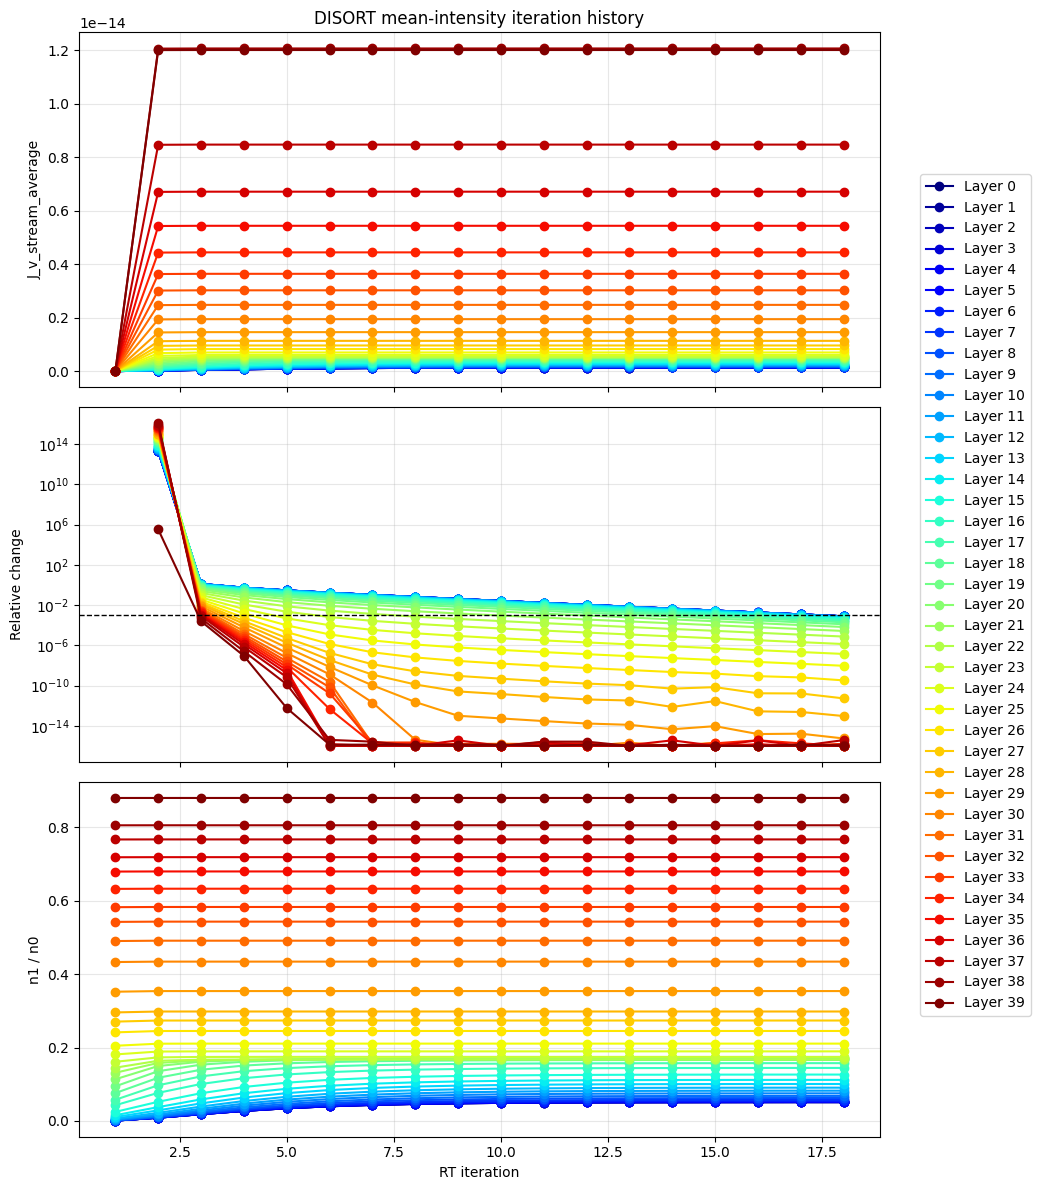

In [9]:
iterations = np.array([item['iteration'] for item in history], dtype=int)
jv_history = np.vstack([item['J_v_stream_average'] for item in history])
rel_history = np.vstack([item['relative_change'] for item in history])
ratio_history = np.vstack([
    item['n_upper'] / np.maximum(item['n_lower'], 1.0e-300)
    for item in history
])

fig, axes = plt.subplots(3, 1, figsize=(9, 12), sharex=True)


norm = mpl.colors.Normalize(vmin=0, vmax=nlayer-1)
cmap = plt.cm.jet



for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[0].plot(iterations, jv_history[:, layer], marker='o', label=f'Layer {layer}', color=color)
axes[0].set_ylabel('J_v_stream_average')
axes[0].set_title('DISORT mean-intensity iteration history')
axes[0].grid(True, alpha=0.3)

for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[1].semilogy(iterations, np.maximum(rel_history[:, layer], 1.0e-16), marker='o', label=f'Layer {layer}', color=color)
axes[1].axhline(1.0e-3, color='k', linestyle='--', linewidth=1.0, label='Convergence threshold')
axes[1].set_ylabel('Relative change')
axes[1].grid(True, alpha=0.3)

for layer in range(nlayer):
    color = cmap(norm(layer))
    axes[2].plot(iterations, np.maximum(ratio_history[:, layer], 1.0e-30), marker='o', label=f'Layer {layer}', color=color)
axes[2].set_xlabel('RT iteration')
axes[2].set_ylabel('n1 / n0')
axes[2].grid(True, alpha=0.3)

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()


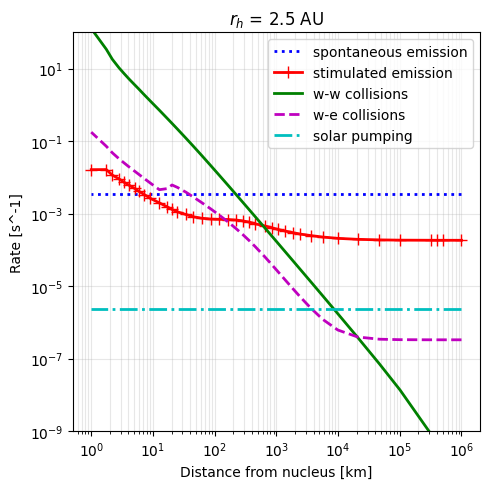

In [10]:
r_km = coma.xc * 1.0e-3
J_nu = np.asarray(final_state['J_v_stream_average'], dtype=np.float64)

A_profile = np.broadcast_to(np.asarray(A_ul_s_1, dtype=np.float64), r_km.shape)
stimulated_profile = np.broadcast_to(np.asarray(B_ul_SI, dtype=np.float64), r_km.shape) * J_nu
Cm_profile = np.broadcast_to(np.asarray(Cm_ul_s_1, dtype=np.float64), r_km.shape)
Ce_profile = np.broadcast_to(np.asarray(Ce_ul_s_1, dtype=np.float64), r_km.shape)
G_profile = np.broadcast_to(np.asarray(G_ul_s_1, dtype=np.float64), r_km.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.loglog(r_km, A_profile, 'b:', lw=2, label=r'spontaneous emission')
ax.loglog(r_km, stimulated_profile, 'r+-', lw=2, markersize=8, label=r'stimulated emission')
ax.loglog(r_km, Cm_profile, 'g-', lw=2, label=r'w-w collisions')
ax.loglog(r_km, Ce_profile, 'm--', lw=2, label=r'w-e collisions')
ax.loglog(r_km, G_profile, 'c-.', lw=2, label=r'solar pumping')
ax.set_ylim(1.0e-9, 1.0e2)
ax.set_xlabel('Distance from nucleus [km]')
ax.set_ylabel('Rate [s^-1]')
ax.set_title(r'$r_h$ = 2.5 AU')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
